# Analyse descriptive des données boursières (Apple)
## Objectif : comprendre le comportement du prix, du volume et des rendements.

### I. Importation des données
Nous chargeons le dataset contenant les prix historiques de l'action Apple afin de préparer l'analyse.

In [1]:
import pandas as pd
df = pd.read_csv("AAPL_Stock_Price_Dataset.csv")

### II. Vérification des données

In [2]:
df.head()

,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,Price_Change
0,1980-12-15,0.093684,0.093684,0.093256,0.093256,175884800,NaN,0.000428,-0.000428
1,1980-12-16,0.086839,0.086839,0.086412,0.086412,105728000,-7.339797,0.000428,-0.000428
2,1980-12-17,0.088550,0.088978,0.088550,0.088550,86441600,2.475132,0.000428,0.000000
3,1980-12-18,0.091118,0.091545,0.091118,0.091118,73449600,2.899260,0.000428,0.000000
4,1980-12-19,0.096678,0.097106,0.096678,0.096678,48630400,6.102835,0.000428,0.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11354 entries, 0 to 11353
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          11354 non-null  object 
 1   Open          11354 non-null  float64
 2   High          11354 non-null  float64
 3   Low           11354 non-null  float64
 4   Close         11354 non-null  float64
 5   Volume        11354 non-null  int64  
 6   Daily_Return  11353 non-null  float64
 7   Price_Range   11354 non-null  float64
 8   Price_Change  11354 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 798.5+ KB


In [4]:
print("Les colonnes qui ont des valeurs nulles: \n",df.isnull().sum())

Les colonnes qui ont des valeurs nulles: 
 Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Daily_Return    1
Price_Range     0
Price_Change    0
dtype: int64


In [5]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


Après vérification, Le dataset contient 11 354 enregistrements et 9 variables. La colonne Date est de type object et doit être convertie en format datetime. Une seule valeur manquante est observée dans Daily_Return, ce qui semble est avec la nature du calcul du rendement. Aucun doublon n’a été détecté.

### III. Conversion des types et validation
La variable Date est convertie en format datetime afin de permettre les analyses temporelles.

In [6]:
df["Date"] = pd.to_datetime(df["Date"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11354 entries, 0 to 11353
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          11354 non-null  datetime64[ns]
 1   Open          11354 non-null  float64       
 2   High          11354 non-null  float64       
 3   Low           11354 non-null  float64       
 4   Close         11354 non-null  float64       
 5   Volume        11354 non-null  int64         
 6   Daily_Return  11353 non-null  float64       
 7   Price_Range   11354 non-null  float64       
 8   Price_Change  11354 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 798.5 KB


La conversion a été effectuée avec succès : Date est maintenant reconnue comme une variable temporelle.

### IV. Gestion de la valeur manquante

La valeur manquante dans Daily_Return correspond à la première enregistrement. Comme le rendement quotidien dépend de la variation entre deux dates, cette absence est normale. Elle sera conservée telle quelle puisqu'elle n'a aucun impacte sur les calcules.

### V. Conclusion de préparation

Les données sont maintenant prêtes pour l’analyse descriptive des prix, du volume et des rendements.

### VI. Analyse Descriptive

#### 1. Analyse descriptive du prix de clôture (Close)

In [8]:
df["Close"].agg(["mean", "median", "min", "max", "std"]).rename({
                                                        "mean" : "Moyenne", 
                                                        "median":"Médiane",
                                                        "min":"Minimum",
                                                        "max":"Maximun",
"std":"ecart-type"})

Moyenne        27.967625
Médiane         0.482590
Minimum         0.037645
Maximun       286.190002
ecart-type     57.823221
Name: Close, dtype: float64

La moyenne(27,97) est largement supérieure à la médiane(0,48) ce qui s'explique par la forte hausse récente des prix qui tire la moyenne vers le haut . Cela montre que la médiane est plus représentative de la distribution. Par ailleurs, l'écart-type(57,82) est peu pertinent ici, car les prix sont non stationnaires.

#### 2. Analyse descriptive du volume

In [9]:
df["Volume"].agg(["mean", "median", "min", "max", "std"]).rename({
                                                        "mean" : "Moyenne", 
                                                        "median"  :"Médiane",
                                                        "min" : "Minimum",
                                                        "max" : "Maximun",
                                                        "std" : "Écart-type"})

Moyenne       3.097171e+08
Médiane       1.988224e+08
Minimum       0.000000e+00
Maximun       7.421641e+09
Écart-type    3.334170e+08
Name: Volume, dtype: float64

la moyenne (310M) est supérieure à la médiane (199M) ce qui indique une distribution asymétrique. Cette différence s'explique par des pics de transactions très élevés, illustrés par le maximum (7,42 milliards). La médiane est donc plus représentative du niveau habituel du volume.

In [10]:
df["Daily_Return"].agg(["mean", "median", "min", "max", "std"]).rename({
                                                        "mean" : "Moyenne", 
                                                        "median" : "Médiane",
                                                        "min" : "Minimum",
                                                        "max" : "Maximun",
                                                        "std" : "Écart-type"})

Moyenne        0.109127
Médiane        0.000000
Minimum      -51.869203
Maximun       33.228052
Écart-type     2.764016
Name: Daily_Return, dtype: float64

En moyenne, le rendement est très faible (0,11%) et la médiane est proche de 0, ce qui indique que la plupart des variations quotidiennes sont limitées. Cependant, l’écart-type est relativement élevé, ce qui traduit une volatilité importante avec des variations parfois significatives illustrés par le minimum (-51,87%) et le maximum (33.23%)

### VII. Graphiques exploratoires 

#### 1. La Courbe d'évolution du prix de clôture dans le temps

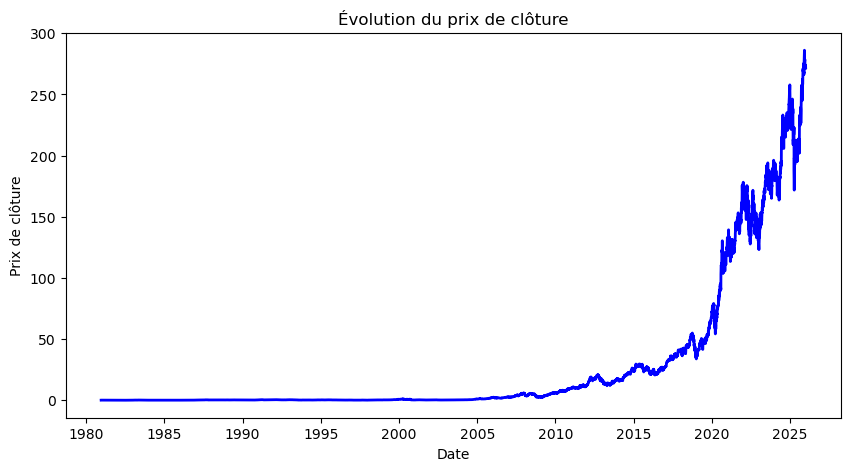

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df.sort_values("Date")
plt.figure(figsize = (10,5))
sns.lineplot(data = df, x="Date", y="Close", color = "blue", linewidth = 2)
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.title("Évolution du prix de clôture")
plt.show()

Le prix de clôture montre une hausse très marquée sur le long terme, particulièrement à partir des années 2000. Cette évolution confirme le caractère non stationnaire de la série de prix.

#### 2. La courbe de l'évolution du volume dans le temps

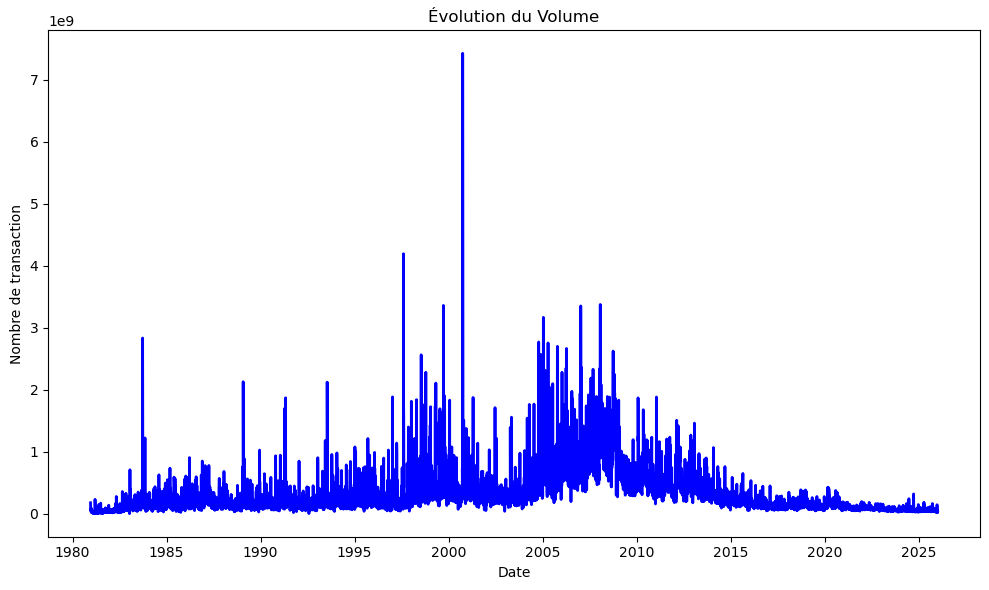

In [12]:
plt.figure(figsize = (10,6))
sns.lineplot(data = df, x="Date", y="Volume", color = "blue", linewidth = 2)
plt.ylabel("Nombre de transaction")
plt.title("Évolution du Volume")
plt.tight_layout()
plt.show()

Le volume présente une forte variabilité dans le temps, avec de nombreux pics d’activité, ce qui confirme une distribution asymétrique. Aucune relation directe avec le prix ne peut être conclue à partir de ce graphique seul.

#### 2. La distribution des rendements journaliers

##### 2-1. L'histogramme de la distribution des rendements journaliers

Pour améliorer la lisibilité de l’histogramme, les rendements extrêmes inférieurs à -10 % et supérieurs à 10 % ont été exclus de ce graphique. Ces valeurs restent prises en compte dans l’analyse descriptive.

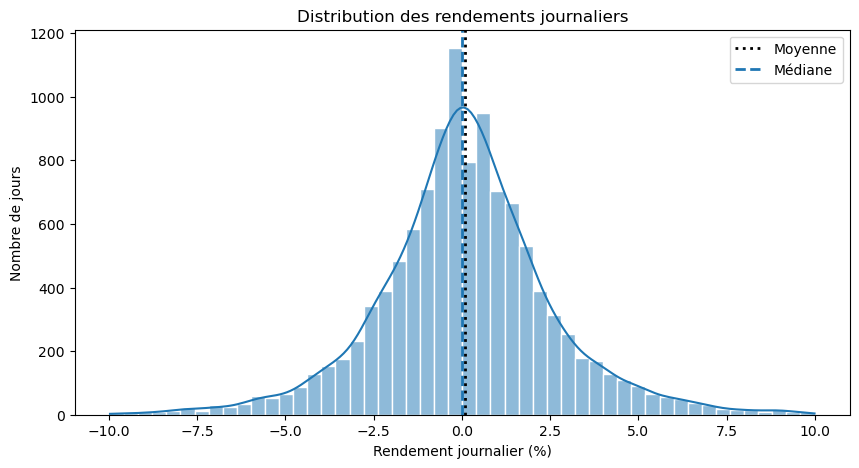

In [13]:
import numpy as np

df_filtrer = df[(df["Daily_Return"] > -10) & (df["Daily_Return"] < 10)]

plt.figure(figsize=(10, 5))
sns.histplot(df_filtrer["Daily_Return"], kde=True, bins=50, edgecolor='white')

mean = np.mean(df_filtrer["Daily_Return"])
median = np.median(df_filtrer["Daily_Return"])

plt.axvline(mean, linestyle=":", color = "black", linewidth=2, label="Moyenne")
plt.axvline(median, linestyle="--", linewidth=2, label="Médiane")

plt.title("Distribution des rendements journaliers")
plt.xlabel("Rendement journalier (%)")
plt.ylabel("Nombre de jours")
plt.legend()
plt.show()

Les rendements sont centrés autour de 0, avec une majorité de variations journalières faibles. La distribution présente toutefois des queues épaisses, ce qui traduit la présence de mouvements extrêmes occasionnels.

##### 2-2. La boîte à moustaches de la distribution des rendements journaliers

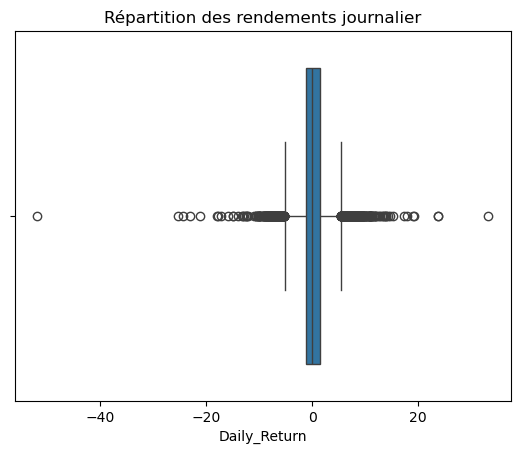

In [14]:
sns.boxplot(x=df["Daily_Return"])
plt.title("Répartition des rendements journalier")
plt.show()

Le boxplot confirme cette observation : la médiane est proche de 0 et la boîte est compacte, traduisant une faible dispersion pour la majorité des données. Cependant, de nombreux outliers sont visibles, ce qui confirme la présence de mouvements extrêmes.

#### 3. Courbe de la Volatilité annuelle de l'écart-type des rendements

In [15]:
tcd_annuel = df.pivot_table(
    index = df["Date"].dt.year,
    values = "Daily_Return",
    aggfunc = "std"
)

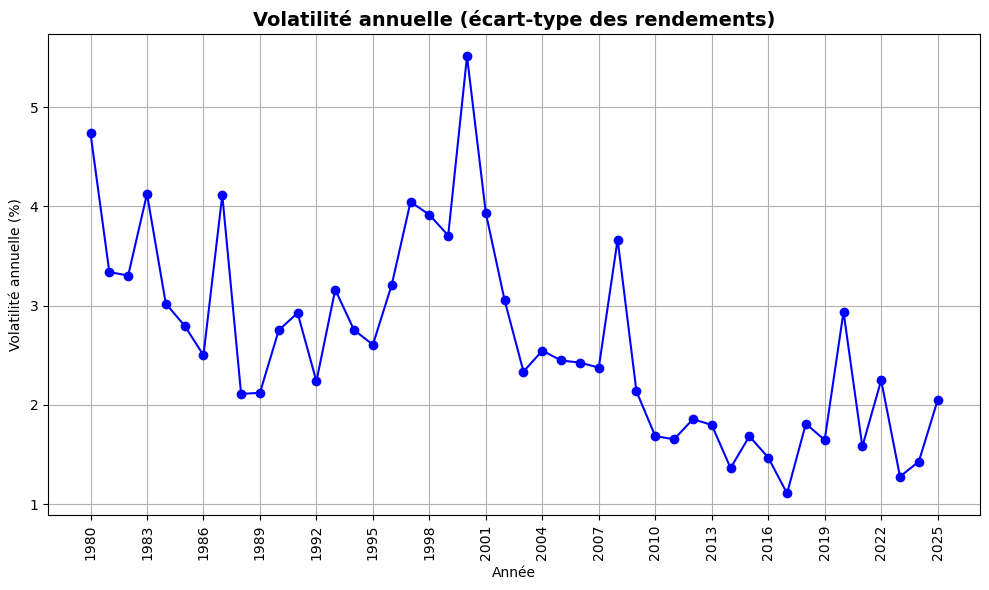

In [16]:
plt.figure(figsize = (10,6))
plt.plot(tcd_annuel.index, tcd_annuel.values, marker = "o", color = "blue")
plt.title("Volatilité annuelle (écart-type des rendements)", fontweight = "bold", size = 14)
plt.xlabel("Année")
plt.ylabel("Volatilité annuelle (%)")
plt.xticks(tcd_annuel.index[::3], rotation=90)
plt.grid()
plt.tight_layout()
plt.show()

La volatilité annuelle varie fortement selon les périodes. Les années de forte instabilité ressortent clairement, notamment autour de la fin des années 1990 et du début des années 2000.